# Simulation Validation

Validate that `simulate_mrca.py` produces realistic MRCA sequences by comparing
simulated vs real naive-to-MRCA mutation distributions (Rodriguez dataset).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from simulate_mrca import load_naive_to_mrca_pcps, RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE
from dnsmex.dxsm_data import filter_valid_pcps

SIM_OUTPUT = "_output/simulated_mrcas_test.csv.gz"

## Load real and simulated data

In [4]:
# Load real naive-to-MRCA PCPs
naive_pcps = load_naive_to_mrca_pcps(RODRIGUEZ_WITH_NAIVE, RODRIGUEZ_NO_NAIVE)
for col in ["parent_light", "child_light"]:
    if col not in naive_pcps.columns:
        naive_pcps[col] = ""
naive_pcps = filter_valid_pcps(naive_pcps).reset_index(drop=True)

naive_pcps["real_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(naive_pcps["parent_heavy"], naive_pcps["child_heavy"])
]
print(f"{len(naive_pcps)} real naive-to-MRCA PCPs")

# Load simulated MRCAs (use first replicate for per-PCP comparison)
sim_df = pd.read_csv(SIM_OUTPUT)
print(f"{len(sim_df)} total simulated rows ({sim_df['replicate'].nunique()} replicates)")

sim_rep0 = sim_df[sim_df["replicate"] == 0].copy()
sim_rep0["sim_muts"] = [
    sum(a != b for a, b in zip(p, c))
    for p, c in zip(sim_rep0["naive_heavy"], sim_rep0["simulated_mrca_heavy"])
]
print(f"{len(sim_rep0)} simulated PCPs in replicate 0")

Filtering PCPs without mutations, or whose ambiguities make them unusable for inference


100%|██████████| 1081/1081 [00:01<00:00, 699.41it/s]


6990 real naive-to-MRCA PCPs
94 total simulated rows (2 replicates)
47 simulated PCPs in replicate 0


## Mutation count distributions: real vs simulated

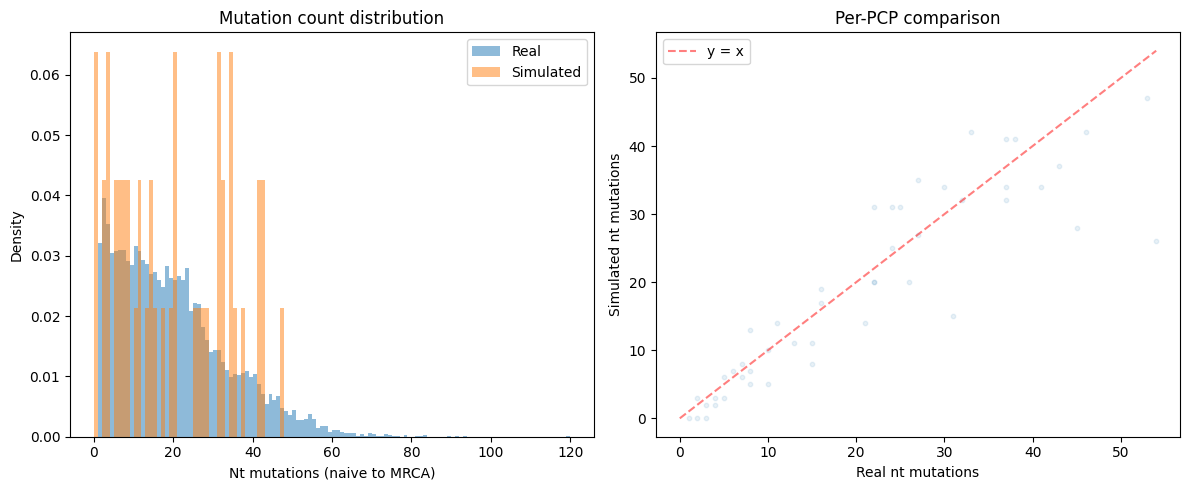

Real:      median=17, mean=19.3
Simulated: median=17, mean=19.1
Ratio sim/real: 0.989


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram comparison
ax = axes[0]
bins = np.arange(0, max(naive_pcps["real_muts"].max(), sim_rep0["sim_muts"].max()) + 2)
ax.hist(naive_pcps["real_muts"], bins=bins, alpha=0.5, label="Real", density=True)
ax.hist(sim_rep0["sim_muts"], bins=bins, alpha=0.5, label="Simulated", density=True)
ax.set_xlabel("Nt mutations (naive to MRCA)")
ax.set_ylabel("Density")
ax.set_title("Mutation count distribution")
ax.legend()

# Per-PCP scatter (merge on family to align real vs simulated)
sim_rep0["family"] = sim_rep0["family"].astype(str)
merged = naive_pcps.merge(
    sim_rep0[["sample_id", "family", "sim_muts"]],
    left_on=["sample_id", "family_str"],
    right_on=["sample_id", "family"],
    how="inner",
)
ax = axes[1]
ax.scatter(merged["real_muts"], merged["sim_muts"], alpha=0.1, s=10)
mx = max(merged["real_muts"].max(), merged["sim_muts"].max())
ax.plot([0, mx], [0, mx], "r--", alpha=0.5, label="y = x")
ax.set_xlabel("Real nt mutations")
ax.set_ylabel("Simulated nt mutations")
ax.set_title("Per-PCP comparison")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Real:      median={naive_pcps['real_muts'].median():.0f}, mean={naive_pcps['real_muts'].mean():.1f}")
print(f"Simulated: median={sim_rep0['sim_muts'].median():.0f}, mean={sim_rep0['sim_muts'].mean():.1f}")
print(f"Ratio sim/real: {sim_rep0['sim_muts'].mean() / naive_pcps['real_muts'].mean():.3f}")

## Per-codon-position mutation frequency: real vs simulated

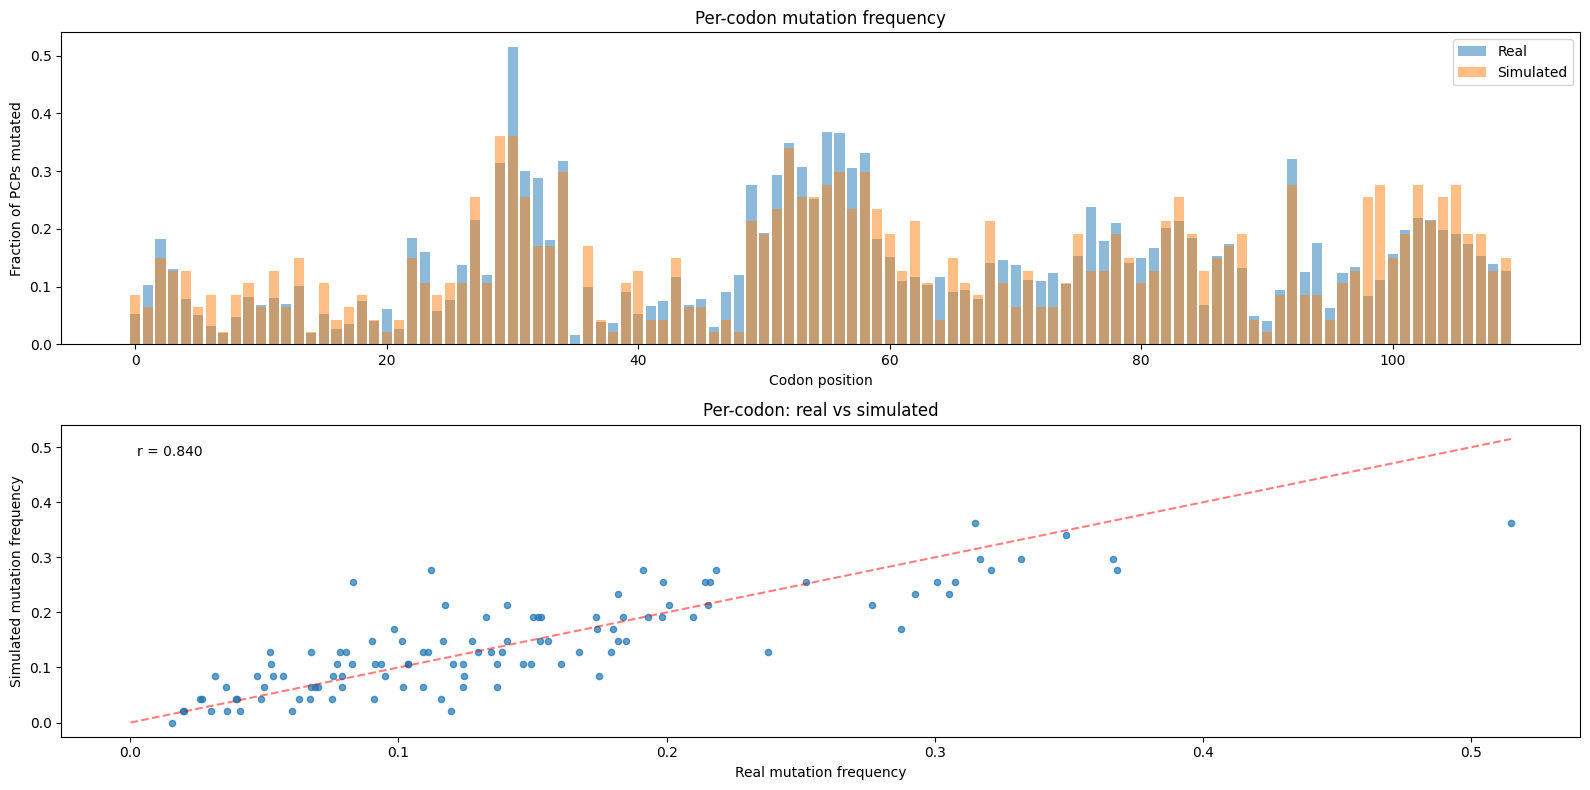

In [7]:
# For each codon position, compute fraction of PCPs with a mutation there
max_codons = naive_pcps["parent_heavy"].str.len().min() // 3

real_site_freq = np.zeros(max_codons)
sim_site_freq = np.zeros(max_codons)
n_real = np.zeros(max_codons)
n_sim = np.zeros(max_codons)

# Real mutations
for _, row in naive_pcps.iterrows():
    naive = row["parent_heavy"]
    mrca = row["child_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_real[c] += 1
        if naive[c*3:(c+1)*3] != mrca[c*3:(c+1)*3]:
            real_site_freq[c] += 1

# Simulated mutations (from saved output)
for _, row in sim_rep0.iterrows():
    naive = row["naive_heavy"]
    sim = row["simulated_mrca_heavy"]
    n_codons = min(len(naive) // 3, max_codons)
    for c in range(n_codons):
        n_sim[c] += 1
        if naive[c*3:(c+1)*3] != sim[c*3:(c+1)*3]:
            sim_site_freq[c] += 1

real_site_freq /= n_real
sim_site_freq /= n_sim

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

ax = axes[0]
ax.bar(range(max_codons), real_site_freq, alpha=0.5, label="Real")
ax.bar(range(max_codons), sim_site_freq, alpha=0.5, label="Simulated")
ax.set_xlabel("Codon position")
ax.set_ylabel("Fraction of PCPs mutated")
ax.set_title("Per-codon mutation frequency")
ax.legend()

ax = axes[1]
ax.scatter(real_site_freq, sim_site_freq, s=20, alpha=0.7)
mx = max(real_site_freq.max(), sim_site_freq.max())
ax.plot([0, mx], [0, mx], "r--", alpha=0.5)
ax.set_xlabel("Real mutation frequency")
ax.set_ylabel("Simulated mutation frequency")
ax.set_title("Per-codon: real vs simulated")
corr = np.corrcoef(real_site_freq, sim_site_freq)[0, 1]
ax.text(0.05, 0.9, f"r = {corr:.3f}", transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Per-V-gene mutation counts

In [8]:
# Aggregate by V gene using merged real+simulated data
merged = naive_pcps.merge(
    sim_rep0[["sample_id", "family", "sim_muts"]],
    left_on=["sample_id", "family_str"],
    right_on=["sample_id", "family"],
    how="inner",
)

vgene_stats = merged.groupby("v_gene_heavy").agg(
    n_pcps=("real_muts", "count"),
    real_mean=("real_muts", "mean"),
    real_median=("real_muts", "median"),
    sim_mean=("sim_muts", "mean"),
    sim_median=("sim_muts", "median"),
).sort_values("n_pcps", ascending=False)

vgene_stats["ratio"] = vgene_stats["sim_mean"] / vgene_stats["real_mean"]

print(f"{'V gene':<20} {'n':>5} {'real_mean':>10} {'sim_mean':>10} {'ratio':>7}")
for vg, row in vgene_stats.head(20).iterrows():
    print(f"{vg:<20} {row['n_pcps']:>5.0f} {row['real_mean']:>10.1f} {row['sim_mean']:>10.1f} {row['ratio']:>7.2f}")

V gene                   n  real_mean   sim_mean   ratio
IGHV3-23*01              6       28.8       24.7    0.86
IGHV1-2*02               3       13.7       16.0    1.17
IGHV3-33*01              3       23.7       21.3    0.90
IGHV1-2*06               3        5.0        4.3    0.87
IGHV1-24*01              2       35.0       32.0    0.91
IGHV1-69*01              2       20.0       22.0    1.10
IGHV4-31*03              2       15.0       12.5    0.83
IGHV4-59*01              2       28.0       23.0    0.82
IGHV5-51*01              2        8.5        4.0    0.47
IGHV4-61*02              2       41.5       38.0    0.92
IGHV1-3*04               1       10.0        5.0    0.50
IGHV1-58*01              1       24.0       31.0    1.29
IGHV1-3*01               1       15.0       11.0    0.73
IGHV1-18*04              1       30.0       34.0    1.13
IGHV3-21*01              1       27.0       35.0    1.30
IGHV3-15*01              1       13.0       11.0    0.85
IGHV3-11*04              1     